In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Predictive Analysis") \
    .getOrCreate()

In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
urllib.request.urlretrieve(url, "chipotle.tsv")

df = spark.read.csv("chipotle.tsv", header=True, sep="\t", inferSchema=True)
df.show(5)

+--------+--------+--------------------+--------------------+----------+
|order_id|quantity|           item_name|  choice_description|item_price|
+--------+--------+--------------------+--------------------+----------+
|       1|       1|Chips and Fresh T...|                NULL|    $2.39 |
|       1|       1|                Izze|        [Clementine]|    $3.39 |
|       1|       1|    Nantucket Nectar|             [Apple]|    $3.39 |
|       1|       1|Chips and Tomatil...|                NULL|    $2.39 |
|       2|       2|        Chicken Bowl|[Tomatillo-Red Ch...|   $16.98 |
+--------+--------+--------------------+--------------------+----------+
only showing top 5 rows


In [3]:
from pyspark.sql.functions import col, regexp_replace

df = df.withColumn(
    "item_price",
    regexp_replace(col("item_price"), "\$", "").cast("float")
)

df = df.dropna()

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_4607/2985763935.py:5: SyntaxWarning: invalid escape sequence '\$'
  regexp_replace(col("item_price"), "\$", "").cast("float")


In [4]:
from pyspark.ml.feature import VectorAssembler

features = ["quantity"]

assembler = VectorAssembler(inputCols=features, outputCol="features")
data = assembler.transform(df)

data.select("features", "item_price").show(5)

+--------+----------+
|features|item_price|
+--------+----------+
|   [1.0]|      2.39|
|   [1.0]|      3.39|
|   [1.0]|      3.39|
|   [1.0]|      2.39|
|   [2.0]|     16.98|
+--------+----------+
only showing top 5 rows


In [5]:
from pyspark.ml.feature import VectorAssembler

features = ["quantity"]

assembler = VectorAssembler(inputCols=features, outputCol="features")
data = assembler.transform(df)

data.select("features", "item_price").show(5)

+--------+----------+
|features|item_price|
+--------+----------+
|   [1.0]|      2.39|
|   [1.0]|      3.39|
|   [1.0]|      3.39|
|   [1.0]|      2.39|
|   [2.0]|     16.98|
+--------+----------+
only showing top 5 rows


In [6]:
train_data, test_data = data.randomSplit([0.8, 0.2])

In [7]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="item_price")

model = lr.fit(train_data)

In [8]:
predictions = model.transform(test_data)

predictions.select("quantity", "item_price", "prediction").show(10)

+--------+----------+-----------------+
|quantity|item_price|       prediction|
+--------+----------+-----------------+
|       1|      2.39|7.268303584815261|
|       1|      1.69|7.268303584815261|
|       1|      8.75|7.268303584815261|
|       1|      3.39|7.268303584815261|
|       1|      1.69|7.268303584815261|
|       1|      8.99|7.268303584815261|
|       1|      2.95|7.268303584815261|
|       1|     10.98|7.268303584815261|
|       1|      3.39|7.268303584815261|
|       1|      3.99|7.268303584815261|
+--------+----------+-----------------+
only showing top 10 rows


In [9]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="item_price",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)
print("RMSE:", rmse)

RMSE: 4.040638838019809


In [10]:
pandas_df = predictions.select("quantity", "item_price", "prediction").toPandas()

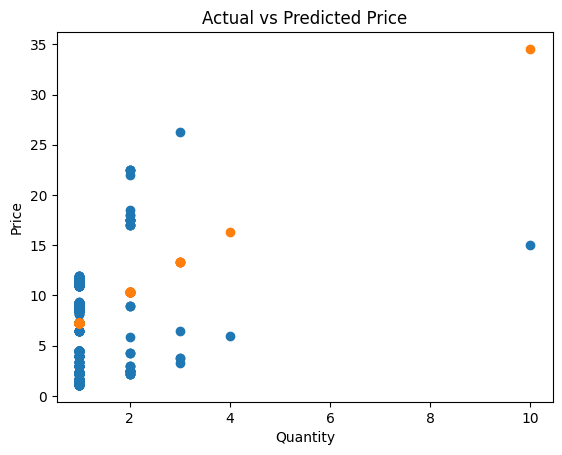

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(pandas_df["quantity"], pandas_df["item_price"])
plt.scatter(pandas_df["quantity"], pandas_df["prediction"])

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Actual vs Predicted Price")

plt.show()

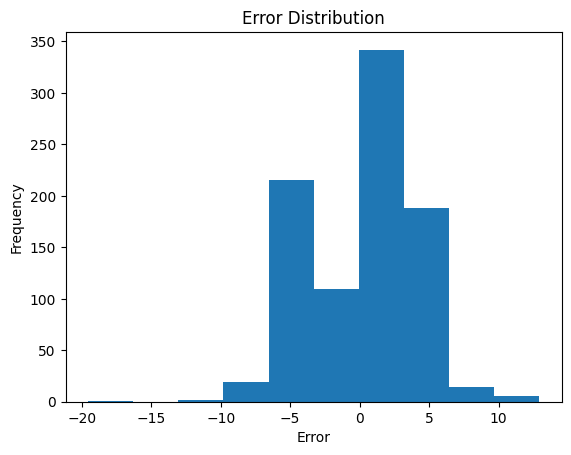

In [12]:
pandas_df["error"] = pandas_df["item_price"] - pandas_df["prediction"]

plt.figure()
plt.hist(pandas_df["error"])

plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

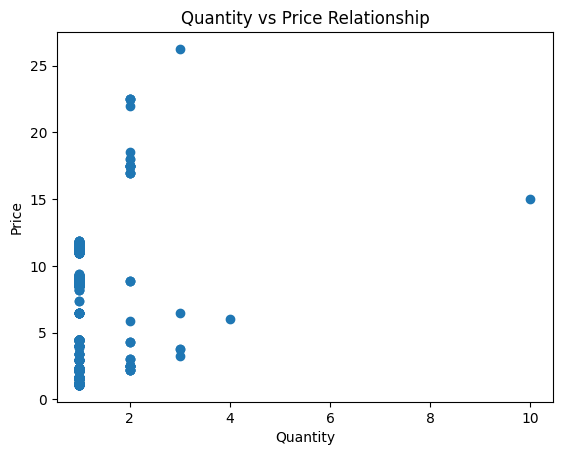

In [13]:
plt.figure()
plt.scatter(pandas_df["quantity"], pandas_df["item_price"])

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Quantity vs Price Relationship")

plt.show()

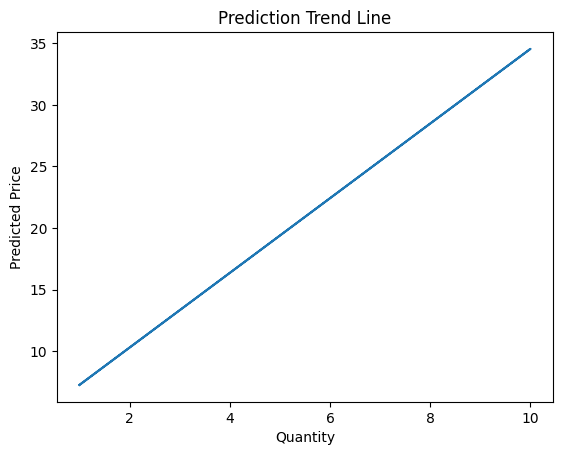

In [14]:
plt.figure()
plt.plot(pandas_df["quantity"], pandas_df["prediction"])

plt.xlabel("Quantity")
plt.ylabel("Predicted Price")
plt.title("Prediction Trend Line")

plt.show()